# Fase 5 — Clusters × Resultado nas Urnas (Desafio pós-eleição)

O TSE divulgou o resultado eleitoral em `DS_SIT_TOT_TURNO`. Aqui investigamos se há **associação entre os 4 clusters construídos na Fase 2** (Base Simbólica, Estruturados, Financiados, Patrimônio Sem Campanha) e o **resultado nas urnas** dos candidatos a Deputado Federal no Nordeste.

**Os clusters não são refeitos**: usamos exatamente as atribuições salvas pelo notebook 02.

## Hipótese do grupo
- Esperamos que os **Estruturados** sejam os mais eleitos e a **Base Simbólica** a menos eleita.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
os.makedirs('images/notebook5', exist_ok=True)

SEMENTE = 42
N_PERM = 10_000
rng = np.random.default_rng(SEMENTE)

ORDEM = ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']
CORES = {'Base Simbólica': '#2b5c8f', 'Estruturados': '#74c476',
         'Financiados': '#e6550d', 'Patrimônio Sem Campanha': '#756bb1'}

## 1) Carga dos dados

Lemos o CSV gerado pelos notebooks 00 (resultado eleitoral) e 02 (clusters).

In [2]:
df = pd.read_csv('dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv')
print(f"{df.shape[0]} candidatos x {df.shape[1]} colunas")
assert df['cluster'].notna().all() and df['DS_SIT_TOT_TURNO'].notna().all()
assert df['SQ_CANDIDATO'].is_unique

print("\nResultado oficial (DS_SIT_TOT_TURNO):")
print(df['DS_SIT_TOT_TURNO'].value_counts())
print("\nClusters:")
print(df['cluster'].value_counts())

2224 candidatos x 71 colunas

Resultado oficial (DS_SIT_TOT_TURNO):
DS_SIT_TOT_TURNO
SUPLENTE            983
NÃO ELEITO          944
#NULO               147
ELEITO POR QP       108
ELEITO POR MÉDIA     42
Name: count, dtype: int64

Clusters:
cluster
Estruturados               1142
Financiados                 453
Base Simbólica              370
Patrimônio Sem Campanha     259
Name: count, dtype: int64


## 2) Variável de resultado

| `DS_SIT_TOT_TURNO` | `RESULTADO_3` | `ELEITO` (binária) |
|---|---|---|
| ELEITO POR QP / ELEITO POR MÉDIA | Eleito | Eleito |
| SUPLENTE | Suplente | Não eleito |
| NÃO ELEITO | Não eleito | Não eleito |
| #NULO | #NULO | Não eleito |

Suplentes não assumem o mandato por voto direto e `#NULO` não teve votação válida. Por isso ambos entram como "não eleito" na análise binária. Na secundária eles aparecem separados.

In [3]:
mapa_bin = {'ELEITO POR QP': 'Eleito', 'ELEITO POR MÉDIA': 'Eleito', 'ELEITO': 'Eleito'}
df['ELEITO'] = df['DS_SIT_TOT_TURNO'].map(mapa_bin).fillna('Não eleito')

mapa_4 = {'ELEITO POR QP': 'Eleito', 'ELEITO POR MÉDIA': 'Eleito', 'ELEITO': 'Eleito',
          'SUPLENTE': 'Suplente', 'NÃO ELEITO': 'Não eleito', '#NULO': '#NULO'}
df['RESULTADO'] = df['DS_SIT_TOT_TURNO'].map(mapa_4)
assert df['RESULTADO'].notna().all()
print(pd.crosstab(df['DS_SIT_TOT_TURNO'], df['ELEITO']))

ELEITO            Eleito  Não eleito
DS_SIT_TOT_TURNO                    
#NULO                  0         147
ELEITO POR MÉDIA      42           0
ELEITO POR QP        108           0
NÃO ELEITO             0         944
SUPLENTE               0         983


## 2.1) Conferência dos nomes dos clusters (sanidade)

Antes de qualquer teste, conferimos se **o nome de cada cluster bate com o seu perfil** de patrimônio e gasto, tal como batizado na Fase 2. Os rótulos A/B/C/D do K-Means são arbitrários, e um nome amarrado à letra errada inverteria todas as conclusões.

In [4]:
perfil = df.groupby('cluster').agg(
    Qtd=('SQ_CANDIDATO', 'count'),
    Bens_mediana=('Total_Bens', 'median'),
    Despesas_mediana=('Total_Despesas_Contratadas', 'median'),
    Pct_sem_despesa=('Total_Despesas_Contratadas', lambda x: (x == 0).mean() * 100),
).loc[ORDEM]
display(perfil.round(1))

# Guardas: o perfil precisa bater com o nome
assert perfil.loc['Estruturados', 'Despesas_mediana'] == perfil['Despesas_mediana'].max()
assert perfil.loc['Base Simbólica', 'Despesas_mediana'] == 0 and perfil.loc['Base Simbólica', 'Bens_mediana'] == 0
assert perfil.loc['Patrimônio Sem Campanha', 'Despesas_mediana'] == 0 and perfil.loc['Patrimônio Sem Campanha', 'Bens_mediana'] > 0
assert perfil.loc['Financiados', 'Despesas_mediana'] > 0 and perfil.loc['Financiados', 'Bens_mediana'] == 0
print('OK: nomes dos clusters coerentes com o perfil.')

,Qtd,Bens_mediana,Despesas_mediana,Pct_sem_despesa
cluster,,,,
Estruturados,1142,400000.0,161875.1,0.0
Financiados,453,0.0,33906.5,0.0
Base Simbólica,370,0.0,0.0,97.0
Patrimônio Sem Campanha,259,140000.0,0.0,94.6


OK: nomes dos clusters coerentes com o perfil.


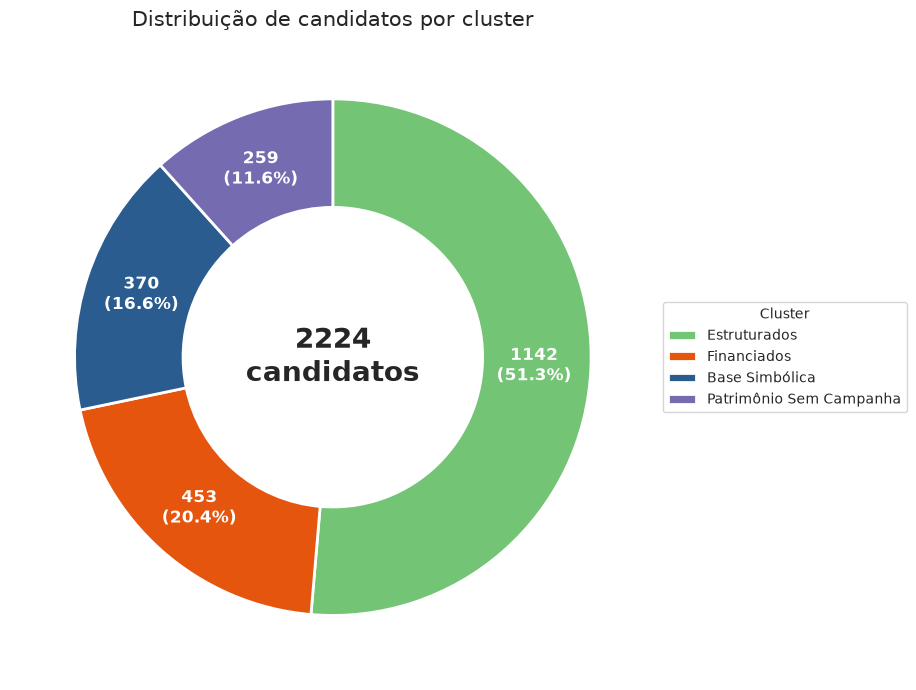

In [5]:
cont = df['cluster'].value_counts().reindex(ORDEM)
fig, ax = plt.subplots(figsize=(9, 7))
wedges, _, autot = ax.pie(cont, colors=[CORES[c] for c in cont.index], startangle=90, counterclock=False,
                          autopct=lambda p: f'{p * cont.sum() / 100:.0f}\n({p:.1f}%)', pctdistance=0.78,
                          wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
                          textprops=dict(color='white', fontweight='bold', fontsize=12))
ax.text(0, 0, f'{cont.sum()}\ncandidatos', ha='center', va='center', fontsize=20, fontweight='bold')
ax.legend(wedges, cont.index, title='Cluster', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Distribuição de candidatos por cluster', fontsize=15)
plt.tight_layout(); plt.savefig('images/notebook5/00_distribuicao_clusters_donut.png', dpi=300, bbox_inches='tight'); plt.show()

## 2.2) Quantidade de candidatos por resultado e cluster

Barras empilhadas com o total de cada resultado, seguidas da tabela correspondente.

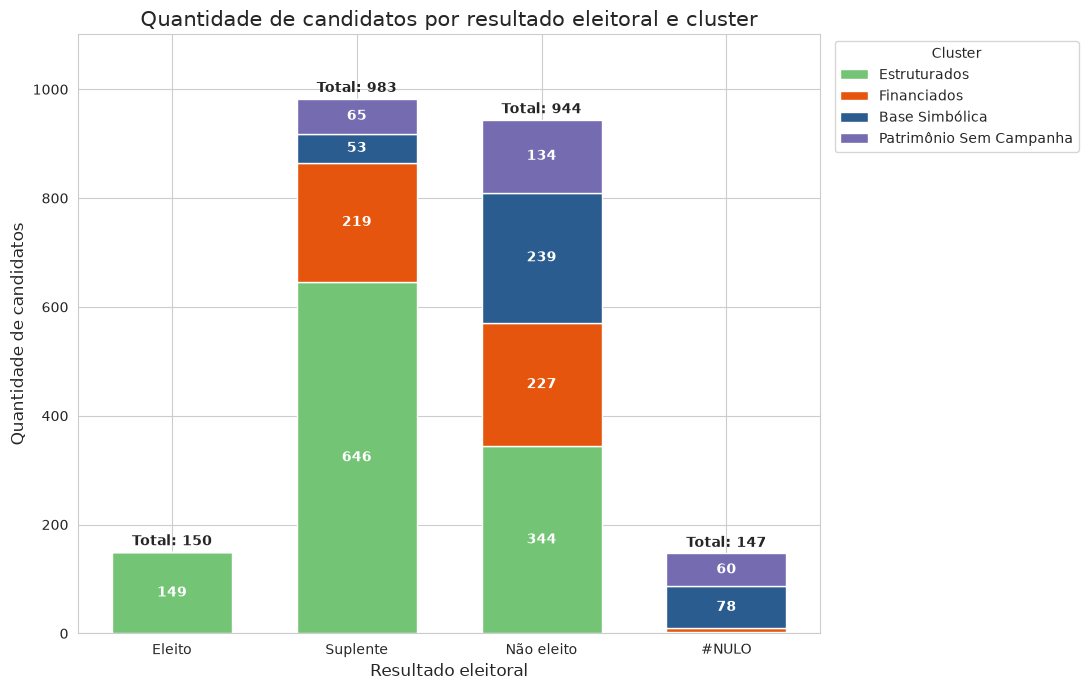

cluster,Estruturados,Financiados,Base Simbólica,Patrimônio Sem Campanha,Total
RESULTADO,,,,,
Eleito,149,1,0,0,150
Suplente,646,219,53,65,983
Não eleito,344,227,239,134,944
#NULO,3,6,78,60,147


In [6]:
ORD_RES = ['Eleito', 'Suplente', 'Não eleito', '#NULO']
q = pd.crosstab(df['RESULTADO'], df['cluster']).reindex(index=ORD_RES, columns=ORDEM)
fig, ax = plt.subplots(figsize=(11, 7))
base = np.zeros(len(q))
for cl in ORDEM:
    vals = q[cl].to_numpy()
    ax.bar(q.index, vals, bottom=base, color=CORES[cl], label=cl, width=0.65, edgecolor='white')
    for i, v in enumerate(vals):
        if v >= 0.03 * q.sum(axis=1).max():
            ax.text(i, base[i] + v / 2, int(v), ha='center', va='center', color='white', fontweight='bold')
    base += vals
for i, tot in enumerate(q.sum(axis=1)):
    ax.text(i, tot + 12, f'Total: {tot}', ha='center', fontweight='bold')
ax.set_ylim(0, q.sum(axis=1).max() * 1.12)
ax.set_xlabel('Resultado eleitoral', fontsize=12); ax.set_ylabel('Quantidade de candidatos', fontsize=12)
ax.set_title('Quantidade de candidatos por resultado eleitoral e cluster', fontsize=15)
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.savefig('images/notebook5/01a_quantidade_resultado_cluster.png', dpi=300, bbox_inches='tight'); plt.show()
display(q.assign(Total=q.sum(axis=1)).rename_axis('RESULTADO'))

## 2.3) Resultados dentro de cada cluster × clusters dentro de cada resultado

À esquerda, o **destino** de cada cluster (soma 100% por barra de cluster). À direita, a **composição** de cada resultado (soma 100% por barra de resultado).

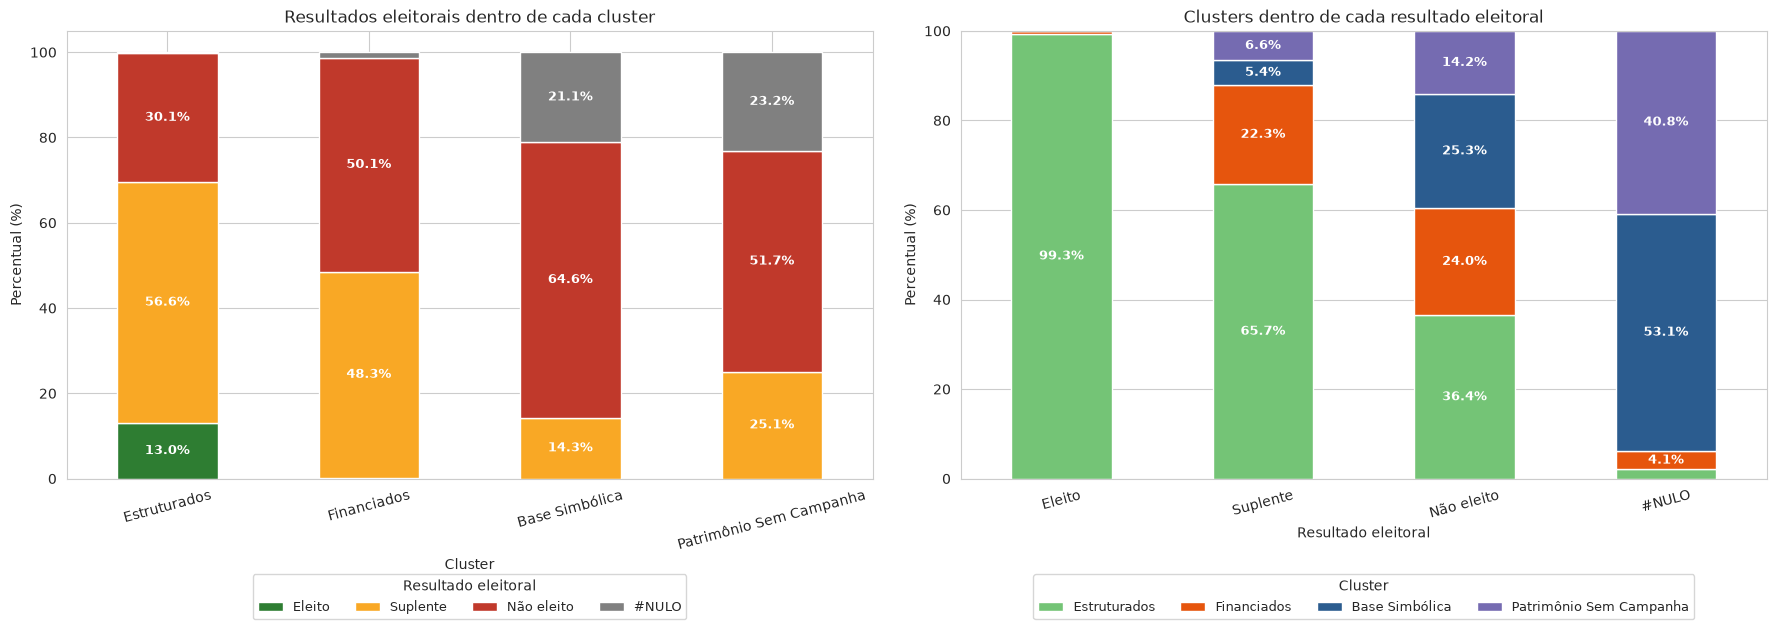

In [7]:
CORES_RES = {'Eleito': '#2e7d32', 'Suplente': '#f9a825', 'Não eleito': '#c0392b', '#NULO': '#808080'}
res_in_cl = pd.crosstab(df['cluster'], df['RESULTADO'], normalize='index').reindex(index=ORDEM, columns=ORD_RES) * 100
cl_in_res = pd.crosstab(df['RESULTADO'], df['cluster'], normalize='index').reindex(index=ORD_RES, columns=ORDEM) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
res_in_cl.plot(kind='bar', stacked=True, ax=axes[0], color=[CORES_RES[c] for c in ORD_RES], width=0.5)
axes[0].set_title('Resultados eleitorais dentro de cada cluster'); axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Percentual (%)')
axes[0].legend(title='Resultado eleitoral', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=9); axes[0].tick_params(axis='x', rotation=15)
cl_in_res.plot(kind='bar', stacked=True, ax=axes[1], color=[CORES[c] for c in ORDEM], width=0.5)
axes[1].set_title('Clusters dentro de cada resultado eleitoral'); axes[1].set_xlabel('Resultado eleitoral'); axes[1].set_ylabel('Percentual (%)')
axes[1].legend(title='Cluster', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=9); axes[1].tick_params(axis='x', rotation=15)
for ax in axes:
    for cont_ in ax.containers:
        ax.bar_label(cont_, labels=[f'{v:.1f}%' if v >= 3 else '' for v in cont_.datavalues],
                     label_type='center', color='white', fontweight='bold', fontsize=9)
plt.tight_layout(); plt.savefig('images/notebook5/01b_percentuais_cruzados.png', dpi=300, bbox_inches='tight'); plt.show()

## 3) Tabela de contingência (análise principal: Eleito × Não eleito)

In [8]:
ct = pd.crosstab(df['cluster'], df['ELEITO']).loc[ORDEM, ['Eleito', 'Não eleito']]
ct_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)
print("Contagens:"); display(ct.assign(Total=ct.sum(axis=1)))
print("% por cluster (linha):"); display(ct_pct)
print(f"Taxa geral de eleição: {ct['Eleito'].sum() / ct.values.sum() * 100:.1f}%")

Contagens:


ELEITO,Eleito,Não eleito,Total
cluster,,,
Estruturados,149,993,1142
Financiados,1,452,453
Base Simbólica,0,370,370
Patrimônio Sem Campanha,0,259,259


% por cluster (linha):


ELEITO,Eleito,Não eleito
cluster,,
Estruturados,13.0,87.0
Financiados,0.2,99.8
Base Simbólica,0.0,100.0
Patrimônio Sem Campanha,0.0,100.0


Taxa geral de eleição: 6.7%


## 4) Interpretação

### Confronto com as hipóteses
- **Confirmada:** os Estruturados são os mais eleitos.
- **Confirmada:** a Base Simbólica é a menos eleita (0 eleitos em 359) e a que mais tem candidaturas anuladas (`#NULO`).
- **Ressalva:** Financiados e Patrimônio Sem Campanha também ficaram praticamente sem eleitos. Ter apenas patrimônio ou apenas campanha financiada não bastou. Os eleitos tinham, em geral, as duas coisas (alto patrimônio e alto gasto de campanha).

### Cuidados na leitura
- **Associação não é causalidade.** Os resultados não mostram que gastar mais ou ter mais patrimônio elege alguém. O sentido pode ser inverso, já que candidatos competitivos atraem mais recursos, ou depender de fatores não controlados, como partido, UF, incumbência, popularidade prévia e número de candidatos na legenda.
- **Circularidade parcial:** o cluster usa a despesa de campanha, e candidatos com `#NULO` ou sem votação tendem a ter campanhas encerradas ou inativas, o que os leva ao cluster sem gastos. Parte da associação reflete isso.
- **Escopo:** a análise cobre apenas Deputado Federal dos 9 estados do Nordeste (151 vagas; 150 eleitos na base, um a menos do que as vagas), como definido no notebook 00, e não o Brasil todo.
- **Atualização da base:** a base pós-eleição tem 35 candidatos a mais do que a usada na Fase 2. Eles receberam cluster ao reexecutar o notebook 02.